<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/pytorch_training__pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

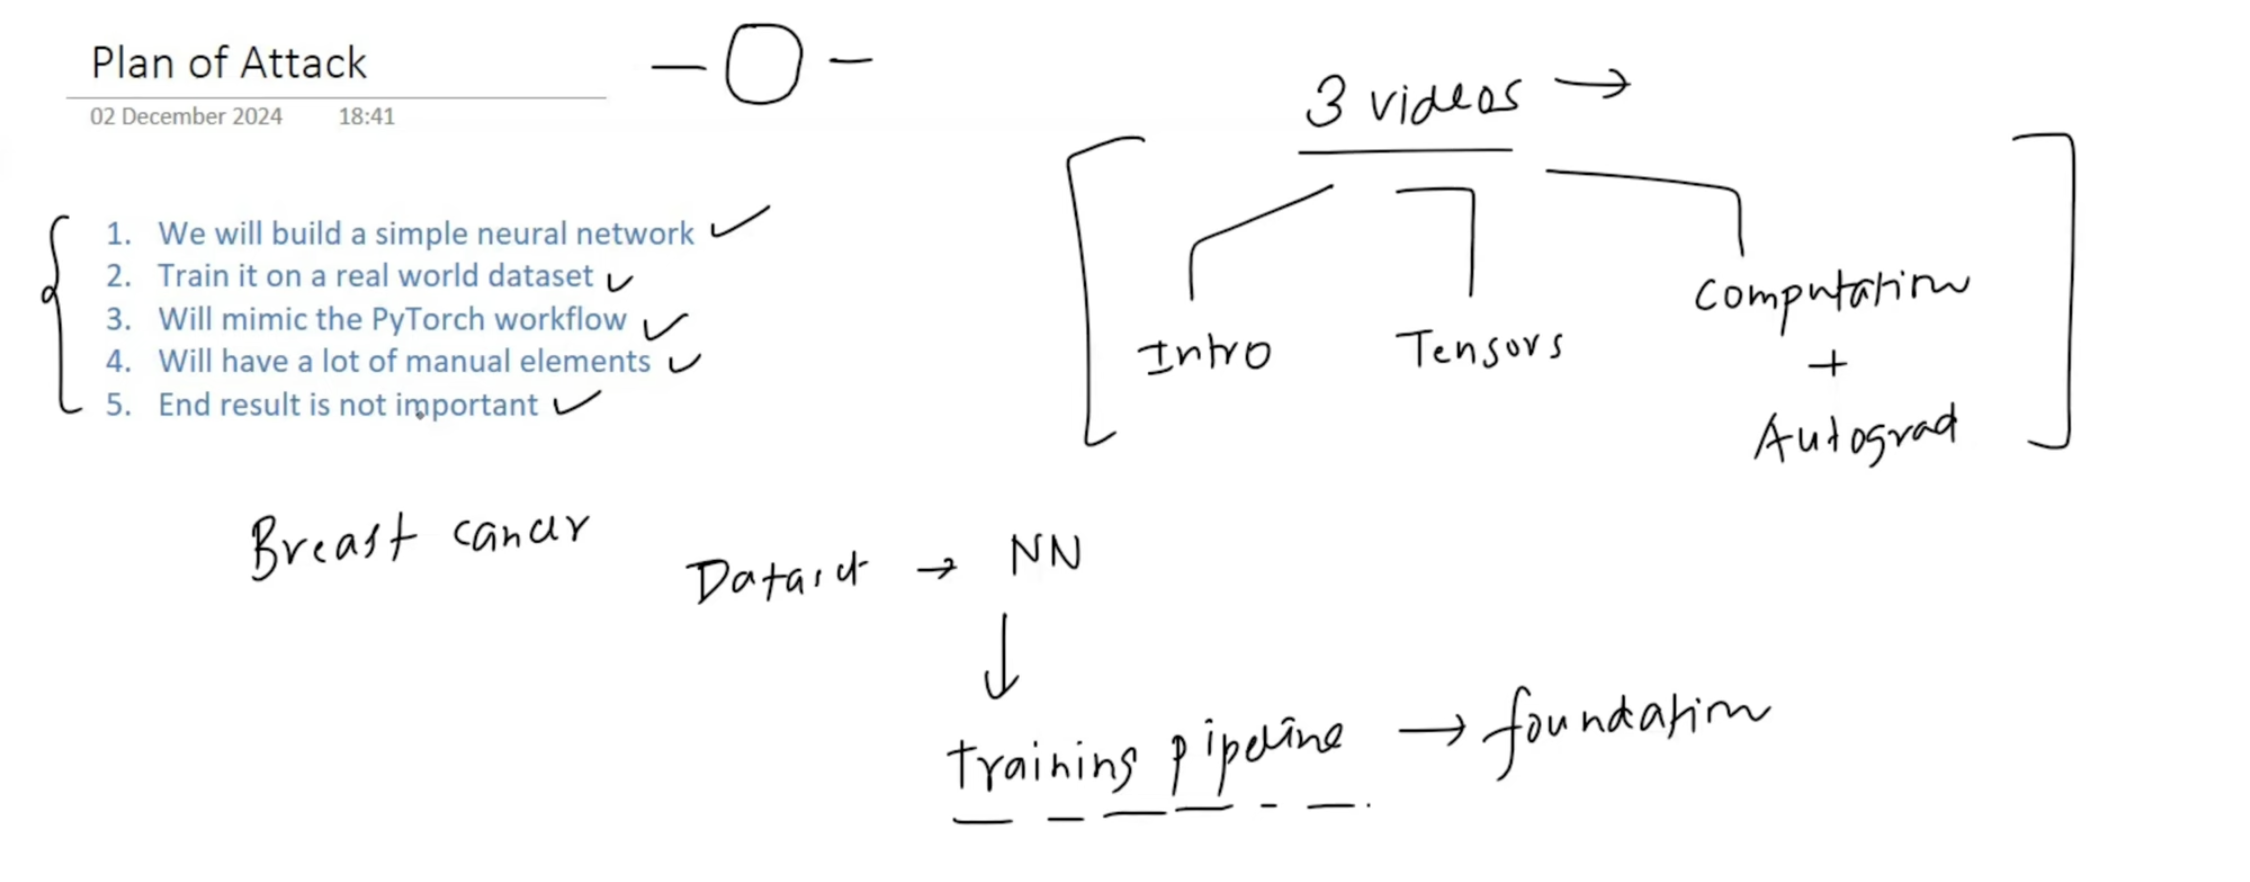







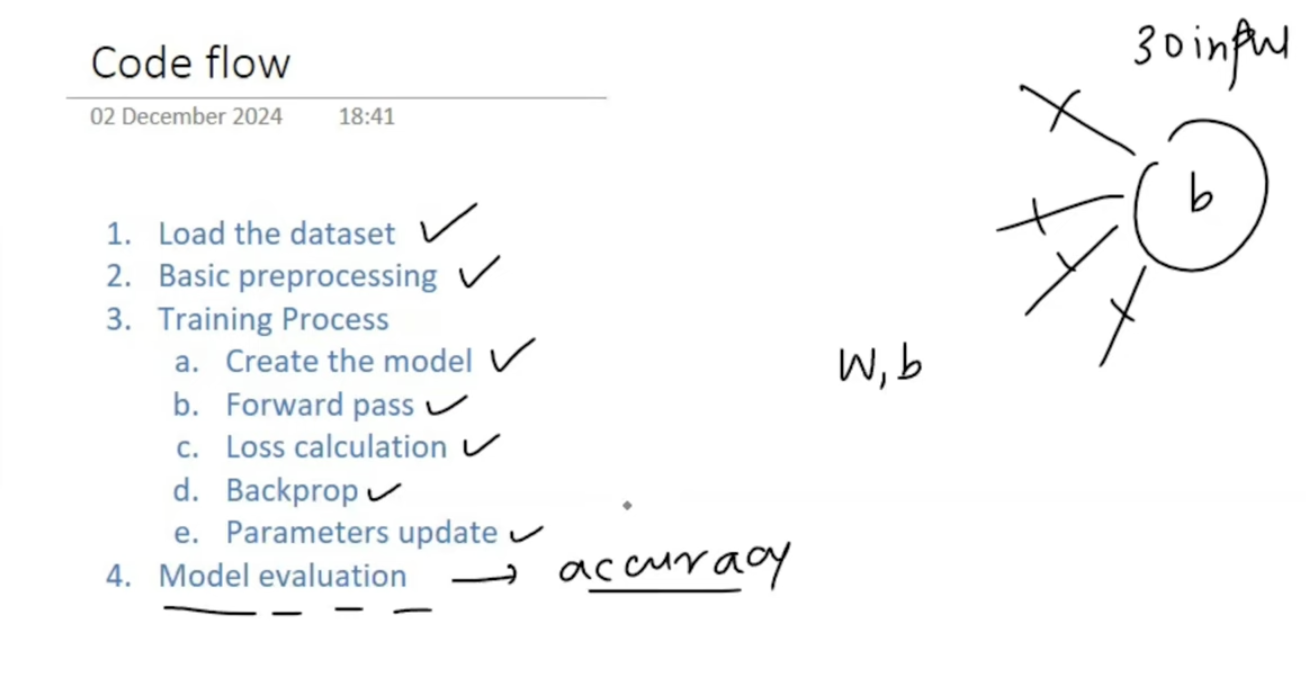

In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.drop(columns=['id' , 'Unnamed: 32'] ,inplace=True) # -> inplace=True -> Original DataFrame ko direct change kar do, naya DataFrame return na karo.

In [6]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [8]:
df.shape

(569, 31)

**train_test_split**


In [9]:
x_train , x_test , y_train , y_test = train_test_split(df.iloc[:,1:] , df.iloc[:,0], test_size=0.2)

**Scaling**

scaling ka mean hai values ko scale kerna jo columns ki values hn un ko same number man convert kerna

hum aysa is lia kerty hn kh jab hum NN man kam kerty hn tu scaling hona zrori hota hai is lia hum ya steps ker rhy hn


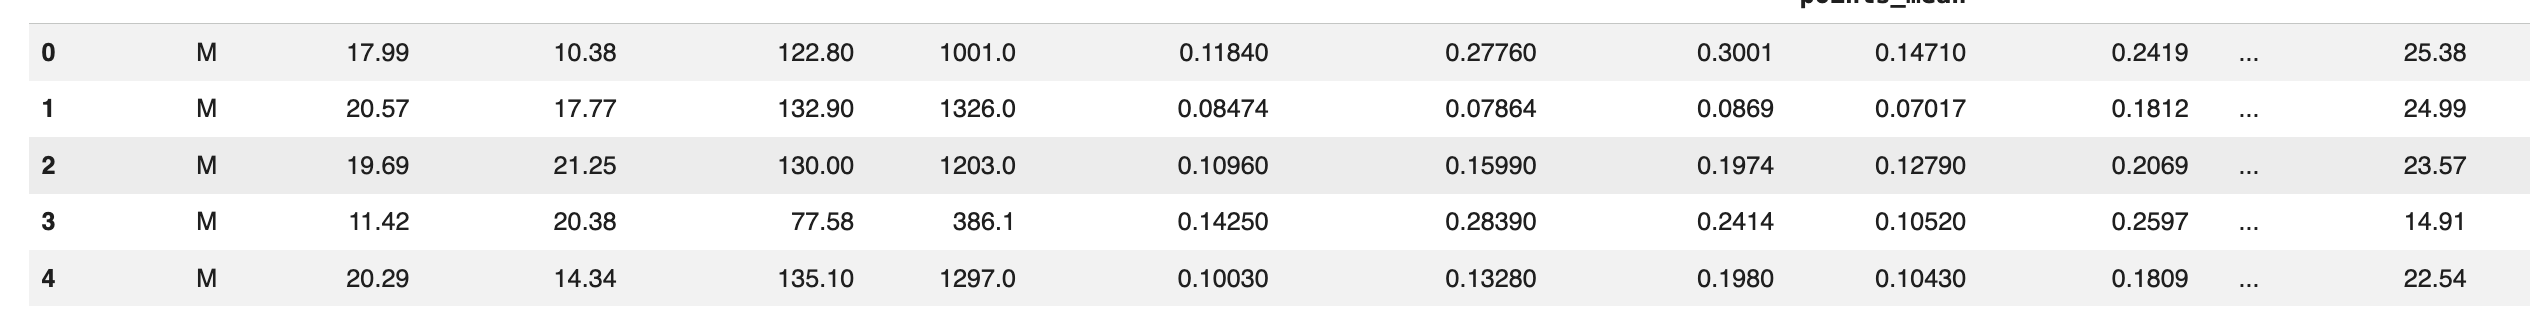









In [10]:
# why we are useing this function
# the answer is we have a dataset which is not same leanth and it would not done the training without equal of data so that
# you can see the uper output values showing not equal
#that is why we use this function
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
x_train

array([[-0.75394755,  0.41072446, -0.74097967, ..., -0.80961549,
        -0.22653035,  0.20806201],
       [-0.77679389, -0.0667706 , -0.80857839, ..., -0.79828611,
         0.56358184, -0.78845114],
       [ 1.82197772,  0.34185498,  1.76882904, ...,  0.68153939,
         0.49004664, -1.11471932],
       ...,
       [-0.26275116, -0.11957054, -0.23934768, ...,  1.38962553,
         1.55396008,  1.78520371],
       [-0.85961189, -1.02635203, -0.88936711, ..., -1.08107336,
        -1.57206793, -0.61726768],
       [-0.62829266,  0.45663745, -0.63463533, ..., -0.49120033,
         0.26318275, -0.59687592]])

In [12]:
y_train

,diagnosis
80,B
289,B
533,M
124,B
164,M
...,...
514,M
122,M
47,M
173,B


**Label Encoder**

ya hum is lia ker rhy hn kah hamara model alphabets ko nae smjh skta is lia hum in ko number man convert kerny lgy hn ta kh hum model per kam ker skyn **diagnosis** column ki value alphabets hn


In [13]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [14]:
y_train

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,

**numpy array to pytorch**

In [15]:
x_train_tensor = torch.from_numpy(x_train)
x_test_tensor = torch.from_numpy(x_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)


In [16]:
x_train_tensor.shape

torch.Size([455, 30])

In [17]:
x_train_tensor.dtype

torch.float64

In [18]:
x_train_tensor

tensor([[-0.7539,  0.4107, -0.7410,  ..., -0.8096, -0.2265,  0.2081],
        [-0.7768, -0.0668, -0.8086,  ..., -0.7983,  0.5636, -0.7885],
        [ 1.8220,  0.3419,  1.7688,  ...,  0.6815,  0.4900, -1.1147],
        ...,
        [-0.2628, -0.1196, -0.2393,  ...,  1.3896,  1.5540,  1.7852],
        [-0.8596, -1.0264, -0.8894,  ..., -1.0811, -1.5721, -0.6173],
        [-0.6283,  0.4566, -0.6346,  ..., -0.4912,  0.2632, -0.5969]],
       dtype=torch.float64)

In [19]:
y_train_tensor.shape

torch.Size([455])

# **Defining the model**

In [20]:


class mysimplenn:
    def __init__(self, x):
      # x.shape[1] means number of features
        self.weight = torch.rand(x.shape[1], 1, dtype=torch.float64, requires_grad=True)
        self.bias = torch.zeros(1, dtype=torch.float64, requires_grad=True)

    def forword(self, x):
        z = torch.matmul(x, self.weight) +  self.bias
        y_pred = torch.sigmoid(z)
        return y_pred

    def loss_function(self, y_pred, y):
        # avoid log(0)
        # Hum is liye use karte hain taake prediction exactly 0 ya 1 na ban jaye.
        epsilon = 1e-7

        # torch.clamp() keeps y_pred between 0.0000001 and 0.9999999
        # so the loss calculation does not break.
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

        # make y shape same as y_pred
        y = y.view(-1, 1).type_as(y_pred)

        # binary cross entropy loss
        loss = -(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred)).mean()

        return loss








# **Iportent parameters**

In [21]:
learning_rate = 0.1
epochs = 25

# **Training pipeline**

In [22]:
# create model
model = mysimplenn(x_train_tensor)


# define loop  -> hum ya jo 4 steps han in ko loop man kerty hain
# kitny dafa hum loop chlay gay ? -> jitni hum nay epoch set kia hai remmeber this words
for epoch in range(epochs):
# 1 .forword pass
   y_pred = model.forword(x_train_tensor)
   #print(y_pred)

# 2 .loss calculate
   loss = model.loss_function(y_pred , y_train_tensor)


# 3 .backword pass

   loss.backward()

# 4 .parameter update
# its a imp step
   with torch.no_grad():
     model.weight -= learning_rate * model.weight.grad
     model.bias -= learning_rate * model.bias.grad

# zeros gradiants
   model.weight.grad.zero_()
   model.bias.grad.zero_()
   # print each epoch utems
   print(f'epoch :"{epoch + 1} , Loss : {loss.item()}')


epoch :"1 , Loss : 0.638057817704812
epoch :"2 , Loss : 0.6192746235724798
epoch :"3 , Loss : 0.6010050605555513
epoch :"4 , Loss : 0.5832400495812466
epoch :"5 , Loss : 0.5659700513159627
epoch :"6 , Loss : 0.5491852994882971
epoch :"7 , Loss : 0.5328759717674332
epoch :"8 , Loss : 0.5170322772147072
epoch :"9 , Loss : 0.5016444625988351
epoch :"10 , Loss : 0.486702756117098
epoch :"11 , Loss : 0.47219727787520355
epoch :"12 , Loss : 0.45811795190876003
epoch :"13 , Loss : 0.44445445418712676
epoch :"14 , Loss : 0.43119622446222067
epoch :"15 , Loss : 0.41833255897181937
epoch :"16 , Loss : 0.4058527852206664
epoch :"17 , Loss : 0.3937465058336714
epoch :"18 , Loss : 0.38200388574899086
epoch :"19 , Loss : 0.3706159502907626
epoch :"20 , Loss : 0.3595748579990477
epoch :"21 , Loss : 0.34887410999563484
epoch :"22 , Loss : 0.3385086571444012
epoch :"23 , Loss : 0.3284748640384386
epoch :"24 , Loss : 0.3187702935882197
epoch :"25 , Loss : 0.3093932917435817


In [23]:
model.weight

tensor([[0.7500],
        [0.1105],
        [0.1358],
        [0.9742],
        [0.8062],
        [0.2567],
        [0.8896],
        [0.3269],
        [0.3160],
        [0.0457],
        [0.2358],
        [0.8467],
        [0.0916],
        [0.2706],
        [0.0962],
        [0.3784],
        [0.6594],
        [0.1306],
        [0.2310],
        [0.5926],
        [0.8535],
        [0.3294],
        [0.8001],
        [0.1991],
        [0.1817],
        [0.0101],
        [0.1387],
        [0.8970],
        [0.1837],
        [0.5037]], dtype=torch.float64, requires_grad=True)

In [24]:
model.bias

tensor([-0.0990], dtype=torch.float64, requires_grad=True)

# **model evaluation**

In [30]:
# model evaluation
with torch.no_grad():
  y_pred = model.forword(x_test_tensor)
print(y_pred)

tensor([[8.0683e-01],
        [6.4074e-01],
        [1.0000e+00],
        [2.7169e-01],
        [4.0559e-04],
        [1.6653e-02],
        [4.0083e-05],
        [4.0558e-05],
        [1.0000e+00],
        [1.2452e-04],
        [8.6698e-01],
        [4.2576e-03],
        [1.1669e-03],
        [7.6821e-04],
        [9.9102e-01],
        [9.0361e-01],
        [1.9867e-03],
        [1.0289e-02],
        [9.9798e-01],
        [7.3842e-05],
        [9.9996e-01],
        [9.9986e-01],
        [4.6887e-02],
        [5.6517e-04],
        [9.9961e-01],
        [6.1912e-02],
        [1.0000e+00],
        [5.1230e-01],
        [7.2442e-04],
        [1.5252e-03],
        [9.4325e-01],
        [1.0000e+00],
        [6.0528e-02],
        [6.7828e-04],
        [9.9996e-01],
        [5.8500e-02],
        [4.6937e-02],
        [5.4014e-02],
        [1.1698e-01],
        [9.9986e-01],
        [1.6457e-01],
        [9.5772e-01],
        [9.8307e-01],
        [1.3717e-03],
        [1.3499e-03],
        [9